# 15.07 - CV Error Analysis

**Notebook type:** Practice notebook with theory, exercises, TODO cells, and test cases.

**Daily output:** A reusable `wrong_prediction_grid()` utility that displays each image with its true label, predicted label, and confidence.

Accuracy and Macro-F1 tell us *how much* a model is wrong. Error analysis helps us understand *why*. Today you will turn validation predictions into a compact report, rank the most confident mistakes, inspect class confusions, and compare performance across blur, lighting, and pose slices.


# 15.07 - CV Error Analysis

**Notebook type:** Practice notebook with theory, exercises, TODO cells, and test cases.

**Daily output:** A reusable `wrong_prediction_grid()` utility that displays each image with its true label, predicted label, and confidence.

Accuracy and Macro-F1 tell us *how much* a model is wrong. Error analysis helps us understand *why*. Today you will turn validation predictions into a compact report, rank the most confident mistakes, inspect class confusions, and compare performance across blur, lighting, and pose slices.


## Core Ideas

### 1. Start with validation predictions

Error analysis must use data that was not used to update model weights. For every validation example, keep the image index, true label, predicted label, class probabilities, confidence, and whether the prediction is correct.

### 2. Confidence is useful but not certainty

For a softmax classifier, confidence is the largest predicted probability. A high-confidence wrong prediction is especially informative: it often reveals a systematic shortcut, a mislabeled sample, or a missing training pattern. Softmax scores need not be calibrated, so treat them as ranking signals rather than guaranteed probabilities of correctness.

### 3. Confusion matrices reveal class-level structure

Rows represent true classes and columns represent predicted classes. Large off-diagonal counts expose recurring class pairs. Always preserve a documented label-to-index mapping so the matrix is interpretable.

### 4. Slice analysis tests hypotheses

Overall metrics can hide weak subgroups. Compare accuracy for slices such as `sharp` versus `blurred`, `bright` versus `dark`, and `front` versus `tilted`. A slice with few samples is a clue, not a final conclusion; record its sample count beside its metric.

### 5. A disciplined loop

Measure, inspect representative failures, form one hypothesis, make one targeted change, and re-measure on the same validation protocol. Avoid changing augmentation, architecture, loss, and data cleaning simultaneously because the source of improvement becomes unclear.


In [1]:
import numpy as np
import torch
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

CLASS_NAMES = ["circle", "square", "triangle"]


## Prepared Validation Data

The cell below provides a deterministic mini validation set. Each image has a class-colored shape-like patch plus controlled brightness and blur metadata. The logits deliberately include several confident mistakes so the diagnostic utilities have meaningful cases to inspect. Data preparation is complete and is not an exercise.

**Return structure — `make_day15_validation_data(...)`:** a 4-tuple `(images, labels, logits, slices)`:

- `images`: `torch.Tensor`, `float32`, CPU, shape `[N, 3, H, W]`
- `labels`: `torch.Tensor`, `long`, CPU, shape `[N]`
- `logits`: `torch.Tensor`, `float32`, CPU, shape `[N, C]`
- `slices`: `dict[str, list[str]]` with keys `blur`, `lighting`, and `pose`; every list has length `N`


In [2]:
def make_day15_validation_data(n_samples=18, image_size=24):
    images = torch.zeros(n_samples, 3, image_size, image_size, dtype=torch.float32)
    labels = torch.tensor([i % 3 for i in range(n_samples)], dtype=torch.long)
    blur_slice = []
    lighting_slice = []
    pose_slice = []

    yy, xx = np.mgrid[:image_size, :image_size]
    for i in range(n_samples):
        label = int(labels[i])
        brightness = 0.55 if i % 2 == 0 else 0.85
        image = torch.full((3, image_size, image_size), 0.08 * brightness)
        center_x = image_size // 2 + (-2 if i % 3 == 0 else 2 if i % 3 == 1 else 0)
        center_y = image_size // 2
        mask = (xx - center_x) ** 2 + (yy - center_y) ** 2 <= 36
        image[label, torch.from_numpy(mask)] = brightness
        images[i] = image
        blur_slice.append("blurred" if i in [2, 5, 8, 11, 14, 17] else "sharp")
        lighting_slice.append("dark" if i % 2 == 0 else "bright")
        pose_slice.append("tilted" if i % 3 == 0 else "front")

    logits = torch.full((n_samples, 3), -0.8, dtype=torch.float32)
    logits[torch.arange(n_samples), labels] = 2.2
    forced_errors = {2: 1, 5: 0, 8: 1, 11: 0, 14: 0}
    for index, wrong_class in forced_errors.items():
        logits[index] = -1.0
        logits[index, wrong_class] = 3.4
        logits[index, labels[index]] = 0.2

    slices = {
        "blur": blur_slice,
        "lighting": lighting_slice,
        "pose": pose_slice,
    }
    return images, labels, logits, slices


val_images, val_labels, val_logits, val_slices = make_day15_validation_data()
print("images:", tuple(val_images.shape), val_images.dtype)
print("labels:", tuple(val_labels.shape), val_labels.dtype)
print("device:", val_logits.device)
print("label mapping:", dict(enumerate(CLASS_NAMES)))


images: (18, 3, 24, 24) torch.float32
labels: (18,) torch.int64
device: cpu
label mapping: {0: 'circle', 1: 'square', 2: 'triangle'}


## Exercise 15-A: Build Prediction Records

Implement `build_prediction_records(logits, true_labels)`. Apply softmax across classes.

**Return structure:** `list[dict]` of length `N`. Every dictionary has this exact schema:

- `index`: Python `int`
- `true_index`: Python `int`
- `pred_index`: Python `int`
- `confidence`: Python `float`
- `probabilities`: detached CPU `torch.Tensor` with shape `[C]`
- `correct`: Python `bool`


In [9]:
# TODO 15-A
def build_prediction_records(logits, true_labels):
    probabilities = torch.softmax(logits.detach(),dim = 1).cpu()
    confidence, pred_index = probabilities.max(dim = 1)
    correct = pred_index == true_labels
    true_labels_detach = true_labels.detach().cpu()
    records = []
    for i in range(len(logits)) : 
        records.append({
            "index" : i,
            "true_index" : true_labels_detach[i].item(), 
            "pred_index" : pred_index[i].item(),
            "confidence" : confidence[i].item(),
            "probabilities" : probabilities[i],
            "correct" : correct[i].item()
        })
    return records


# Smoke check: run this after implementing the functions above.
prediction_records = build_prediction_records(val_logits, val_labels)
print(
    "record smoke check:", len(prediction_records),
    "mistakes:", sum(not record["correct"] for record in prediction_records),
)


record smoke check: 18 mistakes: 5


## Exercise 15-B: Rank Wrong Predictions

Implement `select_wrong_predictions(records, max_items=6)`. Keep only incorrect records and order them by confidence from highest to lowest. This makes the most confident mistakes the first candidates for visual inspection.

**Return structure:** `list[dict]` containing between `0` and `max_items` records. Each item keeps the exact prediction-record schema from Exercise 15-A.


In [16]:
# TODO 15-B
def select_wrong_predictions(records, max_items=6):
    wrong_pred = [i for i in records if not i["correct"]]
    wrong_pred.sort(key = lambda x : x["confidence"], reverse = True)
    wrong_pred = wrong_pred[:max_items]
    if len(wrong_pred) == 0 : return None
    return wrong_pred

# Smoke check: run this after implementing the functions above.
ranked_mistakes = select_wrong_predictions(prediction_records, max_items=3)
print(
    "ranking smoke check:",
    [(record["index"], round(record["confidence"], 3)) for record in ranked_mistakes],
)


ranking smoke check: [(2, 0.95), (5, 0.95), (8, 0.95)]


## Exercise 15-C: Create the Wrong-Prediction Grid

Implement `wrong_prediction_grid(images, records, class_names, max_items=6, columns=3)`. Use the ranked mistakes from Exercise 15-B. Display CHW tensors as HWC images, clip display values to `[0, 1]`, and title each panel with the true label, predicted label, and confidence. Hide unused axes.

**Return structure:** a 2-tuple `(figure, axes)` where `figure` is a `matplotlib.figure.Figure` and `axes` is a flat `numpy.ndarray` of `matplotlib.axes.Axes` objects, including any unused hidden panels.


grid smoke check: titled panels = 4


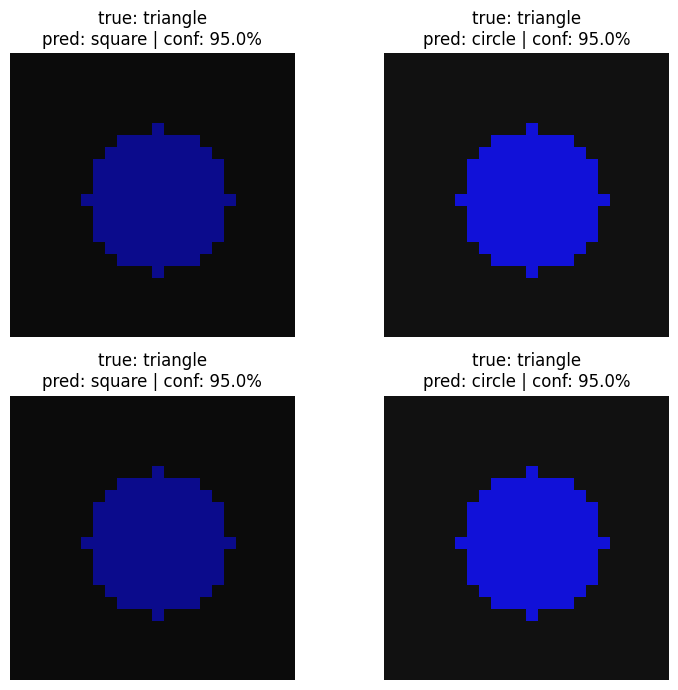

In [17]:
# TODO 15-C
def wrong_prediction_grid(images, records, class_names, max_items=6, columns=3):
    selected = select_wrong_predictions(records, max_items)
    panel_count = max(1, len(selected))
    rows = int(np.ceil(panel_count/columns))
    figure, axe_grid = plt.subplots(rows, columns, figsize = (4 * columns, rows * 3.5))
    axes = np.atleast_1d(axe_grid).reshape(-1)
    for ax in axes : ax.axis("off")
    for ax, selections in zip(axes,selected) :
        image = images[selections["index"]].detach().cpu().permute(1,2,0).numpy()
        if image.shape[2] == 1 :
            ax.imshow(np.clip(image[:,:,0],0.0,1.0), cmap = "gray")
        else : ax.imshow(np.clip(image,0.0,1.0))
        true_name = class_names[selections["true_index"]]
        pred_name = class_names[selections["pred_index"]]
        ax.set_title(f"true: {true_name}\npred: {pred_name} | conf: {selections['confidence']:.1%}")
        ax.axis("off")
    if not selected : 
        axes[0].set_title("No wrong predictions")
    figure.tight_layout()
    return (figure, axes)


# Smoke check: run this after implementing the functions above.
smoke_figure, smoke_axes = wrong_prediction_grid(
    val_images, prediction_records, CLASS_NAMES, max_items=4, columns=2
)
print("grid smoke check: titled panels =", sum(bool(axis.get_title()) for axis in smoke_axes))
plt.show()


## Exercise 15-D: Count and Rank Class Confusions

Implement `confusion_counts(records, num_classes)` so rows are true classes and columns are predictions. Then implement `top_confusions(matrix, class_names, top_k=3)` to rank the largest non-diagonal confusions and exclude zero-count pairs.

**Return structure — `confusion_counts(...)`:** a CPU `torch.Tensor` with dtype `torch.long` and shape `[C, C]`; rows are true classes and columns are predicted classes.

**Return structure — `top_confusions(...)`:** `list[dict]` with at most `top_k` items. Each dictionary is `{'true_label': str, 'pred_label': str, 'count': int}`.


In [19]:
# TODO 15-D
def confusion_counts(records, num_classes):
    matrix = torch.zeros((num_classes, num_classes), dtype = torch.long)
    for record in records : 
        matrix[record["true_index"],record["pred_index"]] += 1
    return matrix


def top_confusions(matrix, class_names, top_k=3):
    confusions = []
    for true_index in range(len(matrix)) : 
        for pred_index in range(len(matrix[0])) : 
            count = int(matrix[true_index,pred_index])
            if true_index != pred_index and count > 0 :
                confusions.append({
                    "true_label" : class_names[true_index],
                    "pred_label" : class_names[pred_index],
                    "count" : count
                })
    confusions.sort(key = lambda x : x["count"], reverse = True)
    return confusions[:top_k]


# Smoke check: run this after implementing the functions above.
confusion_matrix = confusion_counts(prediction_records, len(CLASS_NAMES))
confusion_pairs = top_confusions(confusion_matrix, CLASS_NAMES, top_k=3)
print("confusion-matrix smoke check:")
print(confusion_matrix)
print("top-confusion smoke check:", confusion_pairs)


confusion-matrix smoke check:
tensor([[6, 0, 0],
        [0, 6, 0],
        [3, 2, 1]])
top-confusion smoke check: [{'true_label': 'triangle', 'pred_label': 'circle', 'count': 3}, {'true_label': 'triangle', 'pred_label': 'square', 'count': 2}]


## Exercise 15-E: Measure Slice Accuracy

Implement `slice_accuracy(records, slice_values)`. Use prediction-record order, validate that the lengths match, and sort slice names for stable reports. Apply it to blur, lighting, and pose metadata before deciding which data or augmentation change to try next.

**Return structure:** `dict[str, dict]`. Each outer key is a unique slice name. Its value has the exact schema `{'count': int, 'correct': int, 'accuracy': float}`.


In [22]:
# TODO 15-E
def slice_accuracy(records, slice_values):
    if len(records) != len(slice_values) : 
        raise ValueError()
    report = {}
    for slices in sorted(set(slice_values)) : 
        matching = [record for record, values in zip(records, slice_values) if values == slices]
        correct = sum([record["correct"] for record in matching])
        report[slices] = {
            "count" : len(matching),
            "correct" : correct,
            "accuracy" : correct/len(matching)
        }
    return report


# Smoke check: run this after implementing the functions above.
blur_report = slice_accuracy(prediction_records, val_slices["blur"])
print("slice smoke check:", blur_report)


slice smoke check: {'blurred': {'count': 6, 'correct': 1, 'accuracy': 0.16666666666666666}, 'sharp': {'count': 12, 'correct': 12, 'accuracy': 1.0}}


## Test Cases

Run this cell after completing all TODO cells. The tests check probability shape and normalization, ranking, image-grid titles, confusion counts, slice accounting, and the true/predicted label mapping. A correct implementation prints `Day 15 tests passed`.

**Return structure — `run_day15_tests()`:** `None`. Success is communicated by completed assertions and the printed confirmation.


In [23]:
def run_day15_tests():
    records = build_prediction_records(val_logits, val_labels)
    assert len(records) == len(val_labels)
    assert records[0]["probabilities"].shape == (len(CLASS_NAMES),)
    assert records[0]["probabilities"].dtype == torch.float32
    assert records[0]["probabilities"].device.type == "cpu"
    assert torch.isclose(records[0]["probabilities"].sum(), torch.tensor(1.0), atol=1e-6)
    assert isinstance(records[0]["correct"], bool)

    wrong = select_wrong_predictions(records, max_items=3)
    assert len(wrong) == 3
    assert all(not record["correct"] for record in wrong)
    assert wrong[0]["confidence"] >= wrong[1]["confidence"] >= wrong[2]["confidence"]

    figure, axes = wrong_prediction_grid(val_images, records, CLASS_NAMES, max_items=4, columns=2)
    titled_axes = [axis for axis in axes if axis.get_title()]
    assert len(titled_axes) == 4
    assert all("true:" in axis.get_title() and "pred:" in axis.get_title() for axis in titled_axes)
    plt.close(figure)

    matrix = confusion_counts(records, len(CLASS_NAMES))
    assert matrix.shape == (3, 3)
    assert matrix.dtype == torch.long
    assert int(matrix.sum()) == len(records)
    assert int(matrix.sum() - matrix.diag().sum()) == len(select_wrong_predictions(records, 99))
    confusions = top_confusions(matrix, CLASS_NAMES, top_k=2)
    assert len(confusions) <= 2
    assert all(item["true_label"] != item["pred_label"] for item in confusions)

    blur_report = slice_accuracy(records, val_slices["blur"])
    assert set(blur_report) == {"blurred", "sharp"}
    assert sum(item["count"] for item in blur_report.values()) == len(records)
    assert all(0.0 <= item["accuracy"] <= 1.0 for item in blur_report.values())
    print("Day 15 tests passed")


run_day15_tests()


Day 15 tests passed


## Day 15 Checklist

- [ ] I can explain why high-confidence mistakes are useful but do not prove certainty.
- [ ] I can preserve the label mapping from logits to class names.
- [ ] I can create and read a true-row/predicted-column confusion matrix.
- [ ] My wrong-prediction grid shows image, true label, predicted label, and confidence.
- [ ] I report both sample count and accuracy for each blur, lighting, or pose slice.
- [ ] I can propose one targeted next experiment based on the strongest error pattern.
